# EDA — Sparkov credit-card fraud

Exploratory analysis of the **Sparkov** transactions, run **after** the pipeline so it can use both
the raw CSVs (`data/raw/`) and the engineered feature table (`data/processed/sequences.npz`). Its job
is to **justify the design decisions** — class imbalance → PR-AUC + focal loss; transactions-per-card
→ `sequence_length`; which signals separate fraud — and to act as a **leakage sanity check**
(no single engineered feature should already "solve" the task).

> Prerequisite: run `python -m lean_fraud.data.download` and `python -m lean_fraud.data.build_sequences`
> first (the raw CSVs and `sequences.npz` are git-ignored).

In [1]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
LEGIT, FRAUD = "#4c72b0", "#c44e52"

ROOT = Path.cwd()
if not (ROOT / "data").exists():       # nbconvert runs from notebooks/
    ROOT = ROOT.parent
RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"

USE = ["cc_num", "unix_time", "amt", "lat", "long", "merch_lat", "merch_long",
       "category", "gender", "state", "is_fraud"]
files = [RAW / "fraudTrain.csv", RAW / "fraudTest.csv"]
assert all(f.exists() for f in files), "Run the download + build_sequences steps first."

df = pd.concat([pd.read_csv(f, usecols=USE) for f in files], ignore_index=True)
df["ts"] = pd.to_datetime(df["unix_time"], unit="s")
meta = json.loads((PROC / "meta.json").read_text())
print(f"{len(df):,} transactions | {df['cc_num'].nunique()} cards | "
      f"overall fraud rate {df['is_fraud'].mean():.4%}")
df.head(3)

1,852,394 transactions | 999 cards | overall fraud rate 0.5210%


,cc_num,category,amt,gender,state,lat,long,unix_time,merch_lat,merch_long,is_fraud,ts
0,2703186189652095,misc_net,4.97,F,NC,36.0788,-81.1781,1325376018,36.011293,-82.048315,0,2012-01-01 00:00:18
1,630423337322,grocery_pos,107.23,F,WA,48.8878,-118.2105,1325376044,49.159047,-118.186462,0,2012-01-01 00:00:44
2,38859492057661,entertainment,220.11,M,ID,42.1808,-112.2620,1325376051,43.150704,-112.154481,0,2012-01-01 00:00:51


## 1. Class imbalance

Fraud is **rare** (~0.5%). This is the single most important fact about the problem: it dictates the
metric (**PR-AUC**, not ROC-AUC) and the loss (**focal / class-weighted**), and it means accuracy is
meaningless (predicting "never fraud" scores ~99.5%).

Fraud rate by split (time-based):
  train: 1,296,677 rows   fraud 0.5789%
  val  :   185,239 rows   fraud 0.4297%
  test :   370,478 rows   fraud 0.3641%


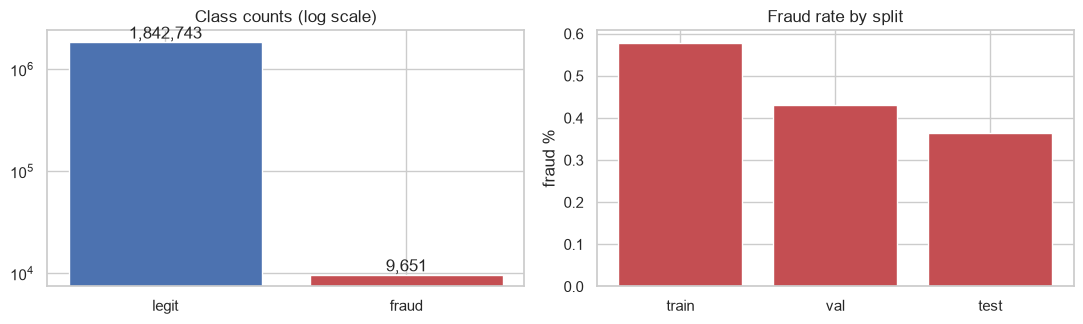

In [2]:
print("Fraud rate by split (time-based):")
for k, v in meta["splits"].items():
    print(f"  {k:5s}: {v['rows']:>9,} rows   fraud {v['fraud_rate']:.4%}")

counts = df["is_fraud"].value_counts().sort_index()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(["legit", "fraud"], counts.values, color=[LEGIT, FRAUD])
ax[0].set_yscale("log")
ax[0].set_title("Class counts (log scale)")
for i, c in enumerate(counts.values):
    ax[0].text(i, c, f"{c:,}", ha="center", va="bottom")
rates = [meta["splits"][s]["fraud_rate"] * 100 for s in ("train", "val", "test")]
ax[1].bar(["train", "val", "test"], rates, color=FRAUD)
ax[1].set_ylabel("fraud %")
ax[1].set_title("Fraud rate by split")
plt.tight_layout()

## 2. Fraud rate over time (temporal drift)

The time-based split already hints at **distribution shift**: the fraud rate falls from train to test
(0.58% → 0.43% → 0.36%). Plotting the monthly fraud rate makes it explicit — the most recent period
(our test set) carries *less* fraud, so the model must generalize across a changing base rate and the
headline metric is computed on the harder, more recent data. Dashed lines mark the split cutoffs.

month
2012-01-01    0.963
2012-02-01    1.037
2012-03-01    0.696
2012-04-01    0.552
2012-05-01    0.563
2012-06-01    0.411
2012-07-01    0.382
2012-08-01    0.437
2012-09-01    0.592
2012-10-01    0.660
2012-11-01    0.551
2012-12-01    0.420
2013-01-01    0.657
2013-02-01    0.703
2013-03-01    0.609
2013-04-01    0.451
2013-05-01    0.709
2013-06-01    0.532
2013-07-01    0.374
2013-08-01    0.468
2013-09-01    0.489
2013-10-01    0.554
2013-11-01    0.405
2013-12-01    0.185
Freq: MS


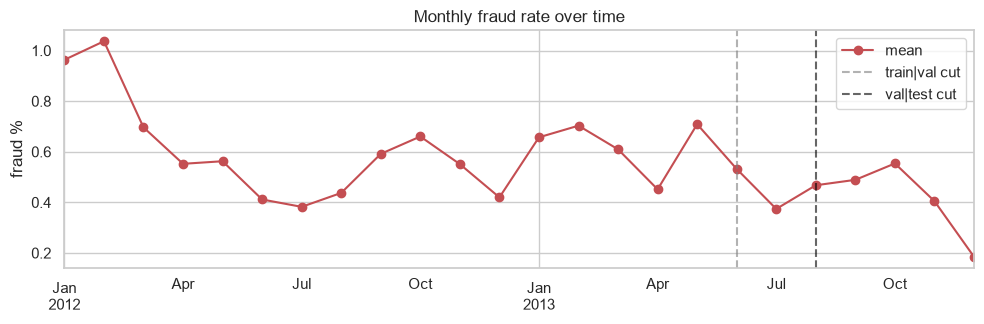

In [3]:
monthly = (df.assign(month=df["ts"].dt.to_period("M"))
             .groupby("month")["is_fraud"].agg(["mean", "size"]))
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 3.4))
(monthly["mean"] * 100).plot(ax=ax, marker="o", color=FRAUD)
for q, c, lbl in [(0.70, "gray", "train|val cut"), (0.80, "black", "val|test cut")]:
    ax.axvline(df["ts"].quantile(q), color=c, ls="--", alpha=0.6, label=lbl)
ax.set_ylabel("fraud %")
ax.set_xlabel("")
ax.set_title("Monthly fraud rate over time")
ax.legend()
plt.tight_layout()
print((monthly["mean"] * 100).round(3).rename("fraud_%").to_string())

## 3. Transactions per card → `sequence_length`

The model scores a card's **recent history**. We need to know how much history exists per card to pick
`sequence_length`. Cards have long histories, so a 32-step window is a *recent slice* (keeps the model
small and fast) and is **full** for the vast majority of transactions.

count     999.0
mean     1854.2
std      1175.6
min         6.0
25%       740.0
50%      1471.0
75%      2917.0
max      4392.0

sequence_length = 32
cards with >= 32 tx: 90.9%
transactions whose card has >= 32 tx: 100.0%


Text(0.5, 1.0, 'Transactions per card')

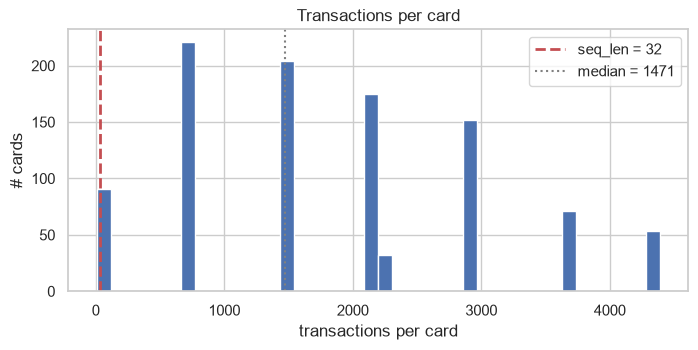

In [4]:
per_card = df.groupby("cc_num").size()
seq_len = meta["sequence_length"]
share_full = (per_card.reindex(df["cc_num"]).to_numpy() >= seq_len).mean()
print(per_card.describe().round(1).to_string())
print(f"\nsequence_length = {seq_len}")
print(f"cards with >= {seq_len} tx: {(per_card >= seq_len).mean():.1%}")
print(f"transactions whose card has >= {seq_len} tx: {share_full:.1%}")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(per_card.values, bins=40, color=LEGIT)
ax.axvline(seq_len, color=FRAUD, ls="--", lw=2, label=f"seq_len = {seq_len}")
ax.axvline(per_card.median(), color="gray", ls=":", label=f"median = {int(per_card.median())}")
ax.set_xlabel("transactions per card")
ax.set_ylabel("# cards")
ax.legend()
ax.set_title("Transactions per card")

## 4. Amount

Amount is a classic fraud signal. Fraudulent transactions tend to cluster at distinctive amounts —
worth a `log1p` transform given the heavy right tail (which is why `amt_log` is an engineered feature).

C:\Users\aleja\AppData\Local\Temp\ipykernel_7896\592284736.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_fraud", y="amt", ax=ax[1], showfliers=False,


C:\Users\aleja\AppData\Local\Temp\ipykernel_7896\592284736.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(["legit", "fraud"])


is_fraud
legit     47.24
fraud    390.00
Name: amt, dtype: float64


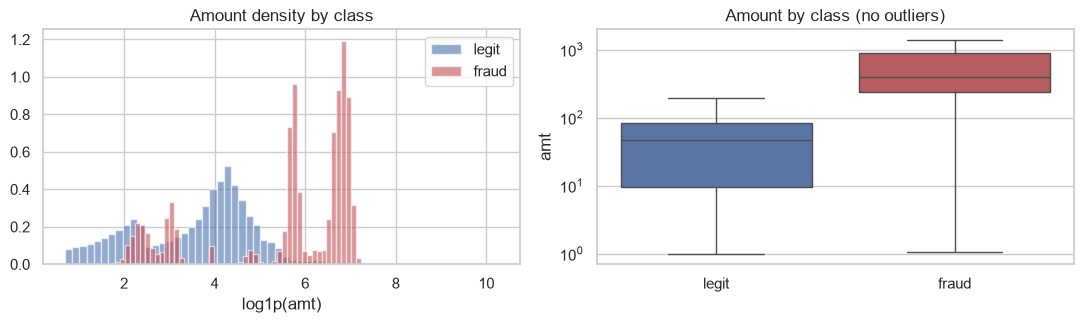

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for lbl, grp in df.groupby("is_fraud"):
    ax[0].hist(np.log1p(grp["amt"]), bins=60, density=True, alpha=0.6,
               color=FRAUD if lbl else LEGIT, label="fraud" if lbl else "legit")
ax[0].set_xlabel("log1p(amt)")
ax[0].set_title("Amount density by class")
ax[0].legend()
sns.boxplot(data=df, x="is_fraud", y="amt", ax=ax[1], showfliers=False,
            palette=[LEGIT, FRAUD])
ax[1].set_yscale("log")
ax[1].set_xticklabels(["legit", "fraud"])
ax[1].set_xlabel("")
ax[1].set_title("Amount by class (no outliers)")
plt.tight_layout()
print(df.groupby("is_fraud")["amt"].median().rename({0: "legit", 1: "fraud"}))

## 5. Temporal patterns (hour / day-of-week)

Fraud often concentrates at unusual hours. `hour` and `dow` are engineered features; here we check
whether the fraud **rate** actually varies with them.

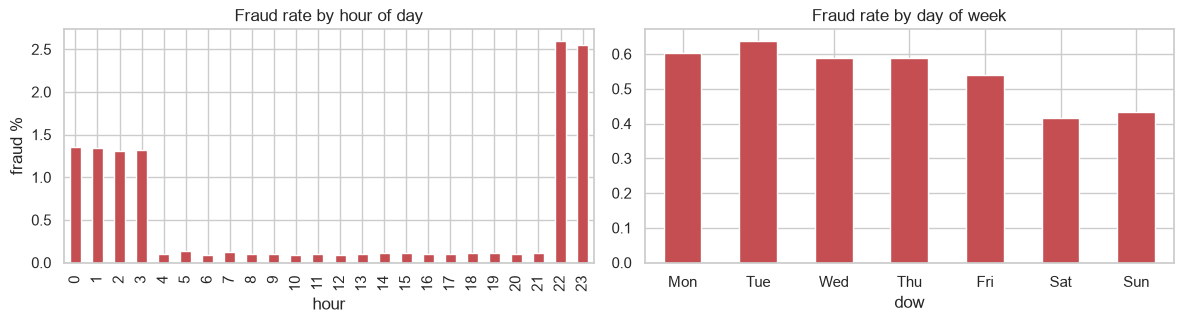

In [6]:
df["hour"] = df["ts"].dt.hour
df["dow"] = df["ts"].dt.dayofweek
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
(df.groupby("hour")["is_fraud"].mean() * 100).plot(kind="bar", ax=ax[0], color=FRAUD)
ax[0].set_ylabel("fraud %")
ax[0].set_title("Fraud rate by hour of day")
(df.groupby("dow")["is_fraud"].mean() * 100).plot(kind="bar", ax=ax[1], color=FRAUD)
ax[1].set_title("Fraud rate by day of week")
ax[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
plt.tight_layout()

## 6. Merchant category

Some categories carry far more fraud than others — a useful categorical signal (`category_code`).

,fraud_%,size
category,,
shopping_net,1.593,139322
misc_net,1.304,90654
grocery_pos,1.265,176191
shopping_pos,0.634,166463
gas_transport,0.411,188029
misc_pos,0.282,114229
grocery_net,0.270,64878
travel,0.269,57956
personal_care,0.223,130085


Text(0.5, 1.0, 'Fraud rate by merchant category')

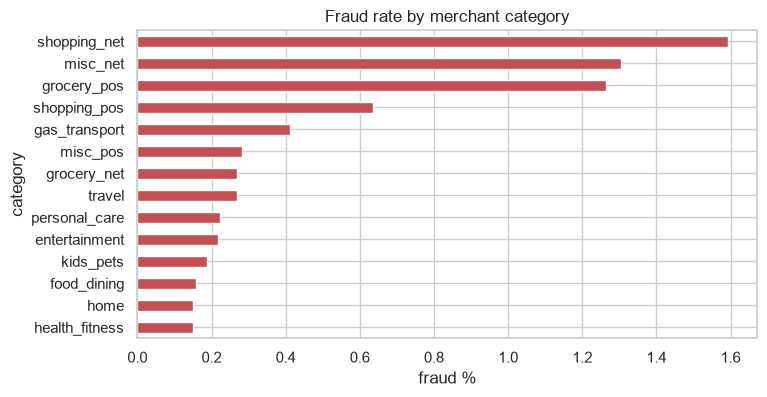

In [7]:
cat = (df.groupby("category")["is_fraud"].agg(["mean", "size"])
         .assign(**{"fraud_%": lambda d: d["mean"] * 100})
         .sort_values("fraud_%", ascending=False))
display(cat[["fraud_%", "size"]].round(3))
fig, ax = plt.subplots(figsize=(8, 4))
cat["fraud_%"].plot(kind="barh", ax=ax, color=FRAUD)
ax.invert_yaxis()
ax.set_xlabel("fraud %")
ax.set_title("Fraud rate by merchant category")

## 7. Feature correlations

Pearson correlations among the engineered features (from `sequences.npz`). High correlations flag
**redundancy** — `amt` and `amt_log` carry almost the same information, and `amt_count` tracks
`amt_roll_mean`. Useful when deciding whether to prune features for the lean model.

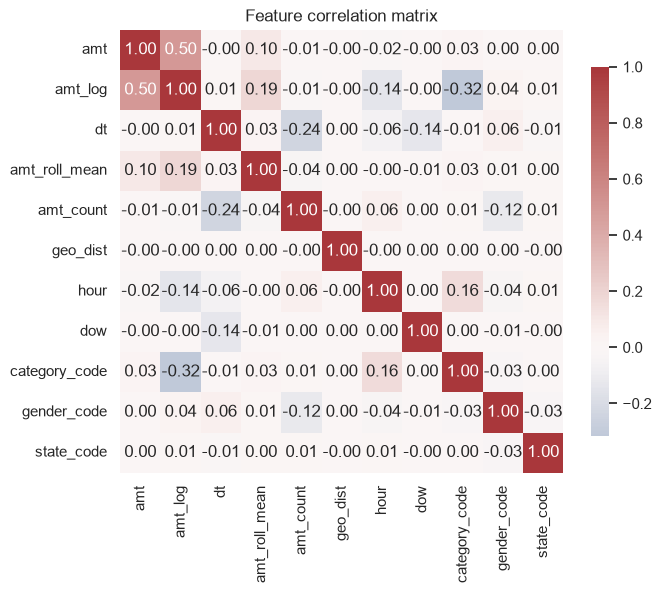

In [8]:
z = np.load(PROC / "sequences.npz")
corr = pd.DataFrame(z["X"], columns=meta["feature_names"]).corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()

## 8. Engineered features — separability & leakage check

For every feature in `sequences.npz`, we compute its **single-feature ROC-AUC on the train split**
(direction-agnostic, so `max(auc, 1-auc)`). Two reads:
- **Separability** — higher = the feature alone discriminates fraud better.
- **Leakage alarm** — if *any* single feature scores ~1.0, something leaked (a label proxy). We expect
  moderate values, not a perfect predictor.

(Categorical codes are ordinal-arbitrary, so their AUC is only a rough proxy.)

amt              0.8346
amt_log          0.8346
dt               0.6517
amt_count        0.6462
amt_roll_mean    0.6001
hour             0.5851
category_code    0.5748
dow              0.5358
gender_code      0.5251
state_code       0.5061
geo_dist         0.5009

Leakage check — any single-feature AUC > 0.95?  False


Text(0.5, 1.0, 'Per-feature separability')

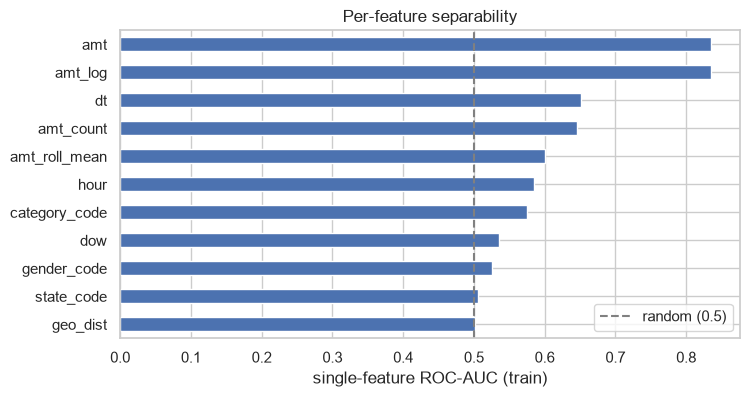

In [9]:
from sklearn.metrics import roc_auc_score

y, split, X = z["y"], z["split"], z["X"]
tr = split == 0
aucs = {name: max(a, 1 - a) for name, a in
        ((n, roc_auc_score(y[tr], X[tr, i])) for i, n in enumerate(meta["feature_names"]))}
auc_s = pd.Series(aucs).sort_values(ascending=False)
print(auc_s.round(4).to_string())
print(f"\nLeakage check — any single-feature AUC > 0.95?  {(auc_s > 0.95).any()}")

fig, ax = plt.subplots(figsize=(8, 4))
auc_s.plot(kind="barh", ax=ax, color=LEGIT)
ax.axvline(0.5, color="gray", ls="--", label="random (0.5)")
ax.invert_yaxis()
ax.set_xlabel("single-feature ROC-AUC (train)")
ax.legend()
ax.set_title("Per-feature separability")

## Takeaways → design decisions

- **Severe imbalance (~0.5% fraud)** → report **PR-AUC** (not ROC-AUC); train with **focal / weighted
  loss** and XGBoost `scale_pos_weight`. Accuracy is not a useful metric here.
- **Temporal drift** → the fraud rate declines over time (0.58% → 0.36% across splits), so the
  time-based split makes the test set genuinely harder; metrics are reported on that recent data.
- **Long per-card histories** → `sequence_length = 32` is a recent-history window that is *full* for the
  large majority of transactions, keeping the TCN small and low-latency (the efficiency thesis).
- **Redundant features** → `amt`/`amt_log` (and `amt_count`/`amt_roll_mean`) are highly correlated —
  candidates to prune for the lean model.
- **Amount, time, category and distance all carry signal**, but **no single feature solves the task**
  (no AUC near 1.0) → the engineered features are informative without leaking the label.